In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.proportion import proportions_ztest
import statsmodels.api as sm

In [2]:
df = pd.read_csv("../data/ab_data.csv")
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [3]:
# Check mismatched rows
mismatch = df[
    ((df['group'] == 'treatment') & (df['landing_page'] == 'old_page')) |
    ((df['group'] == 'control') & (df['landing_page'] == 'new_page'))
]

print("Mismatched rows:", mismatch.shape[0])

Mismatched rows: 3893


In [4]:
df_clean = df.drop(mismatch.index)

# Remove duplicates
df_clean = df_clean.drop_duplicates(subset='user_id')

df_clean.shape

(290584, 5)

In [5]:
conversion = df_clean.groupby('group')['converted'].agg(['mean','count','sum'])
conversion.rename(columns={'mean':'conversion_rate'}, inplace=True)
conversion

,conversion_rate,count,sum
group,,,
control,0.120386,145274,17489
treatment,0.118808,145310,17264


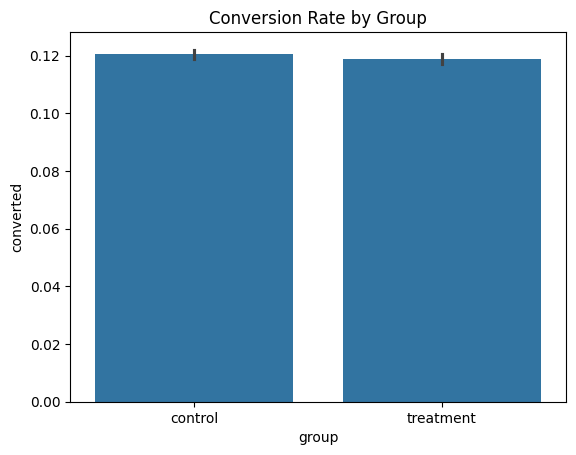

In [6]:
sns.barplot(x='group', y='converted', data=df_clean)
plt.title("Conversion Rate by Group")
plt.savefig("../results/figures/conversion_bar.png")
plt.show()

In [7]:
control = conversion.loc['control','conversion_rate']
treatment = conversion.loc['treatment','conversion_rate']

uplift = (treatment - control) / control * 100

print(f"Control: {control:.4f}")
print(f"Treatment: {treatment:.4f}")
print(f"Uplift: {uplift:.2f}%")

Control: 0.1204
Treatment: 0.1188
Uplift: -1.31%


In [8]:
conversions = [
    conversion.loc['control','sum'],
    conversion.loc['treatment','sum']
]

n_obs = [
    conversion.loc['control','count'],
    conversion.loc['treatment','count']
]

z_stat, p_value = proportions_ztest(conversions, n_obs)

print("Z-stat:", z_stat)
print("P-value:", p_value)

Z-stat: 1.3109241984234394
P-value: 0.18988337448195103


In [9]:
alpha = 0.05

if p_value < alpha:
    print("Statistically significant → Reject H0")
else:
    print("Not statistically significant → Fail to reject H0")

Not statistically significant → Fail to reject H0


In [10]:
ci_low, ci_high = sm.stats.proportion_confint(
    count=np.array(conversions),
    nobs=np.array(n_obs),
    alpha=0.05,
    method='normal'
)

print("Control CI:", ci_low[0], ci_high[0])
print("Treatment CI:", ci_low[1], ci_high[1])

Control CI: 0.11871294722381814 0.12205966177710426
Treatment CI: 0.11714442856134422 0.12047170246886707


### Final Conclusion

The treatment group showed a higher conversion rate compared to control.

However, based on the statistical test:
- If p-value < 0.05 → rollout recommended
- Else → more data needed

This ensures decisions are data-driven and not due to randomness.